
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

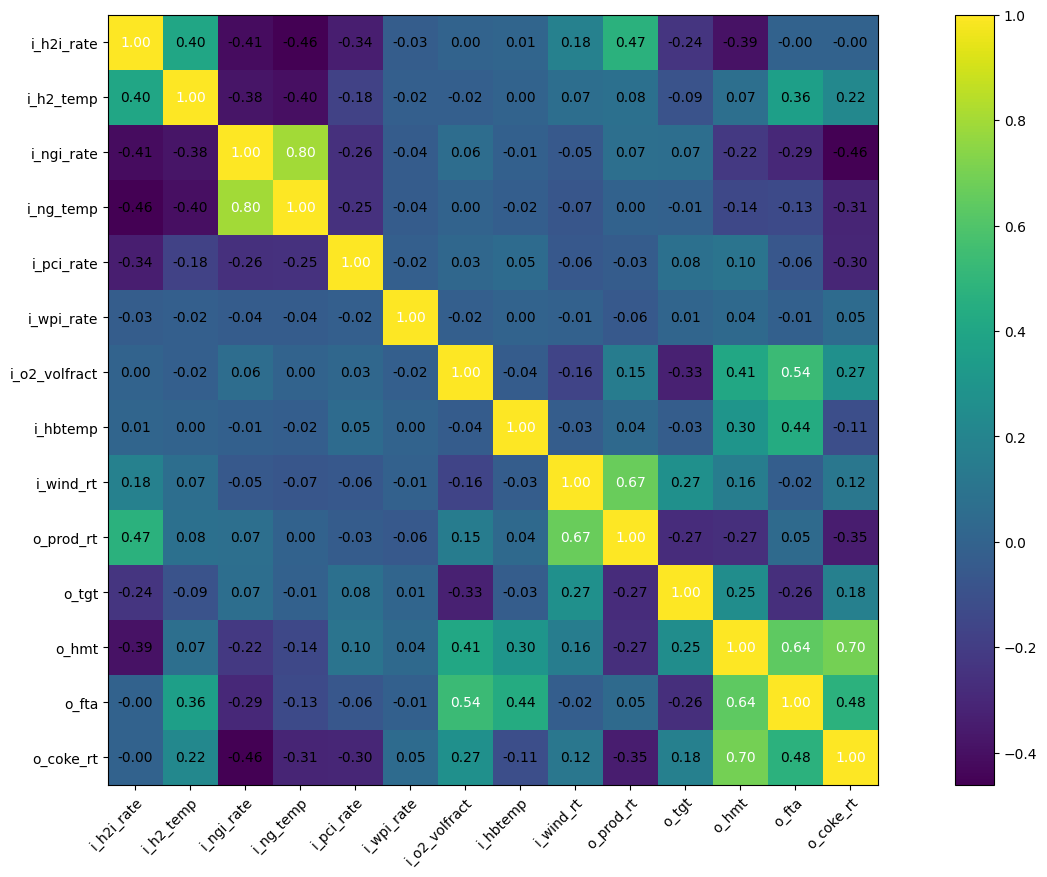

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.9918205738067627
100 ..... 0.2629663944244385
200 ..... 0.4468514621257782
300 ..... 0.27567166090011597
400 ..... 0.477632611989975
500 ..... 0.29304882884025574
600 ..... 0.2891477644443512
700 ..... 0.1359916627407074
800 ..... 0.20321135222911835
900 ..... 0.1604280024766922


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  98.1628, 1296.0936, 8450.9385, 2305.4221,  417.1625]])
y_deviations: tensor([[  50.7959,  522.1684, 1520.4177,  211.3914,   49.6137]])
x_means: tensor([[  12.5931,   18.7069,   41.2568,   25.5994,  414.1786, 1437.5874,
          198.7897]])
x_deviations: tensor([[ 15.4053,  45.0830,  46.6779,   3.3238, 269.5977, 157.6213,  26.5013]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.3668,  773.9252, 6930.5205, 2094.0308,  367.5488]])
tensor([[ 148.9587, 1818.2620, 9971.3564, 2516.8135,  466.7763]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.8122,  -26.3761,   -5.4211,   22.2756,  144.5809, 1279.9662,
          172.2884]])
tensor([[  27.9985,   63.7900,   87.9347,   28.9232,  683.7762, 1595.2086,
          225.2910]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])



get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [32]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [33]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [34]:

lambda_cost = 0.01    ## 0.001   ## this gave 86% percent of cases improvement
## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [35]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    

    for j in range(1000):
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        loss_main  = torch.mean((current_y - target_y)**2)
        ## loss_cost  = lambda_cost * torch.dot(price_real, x_temp)
        loss_cost  = lambda_cost * (x_temp @ price_real)
        loss       = loss_main + loss_cost + loss_z_reg
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 200 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( loss )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')




iteration 0 cost: 648.4345092773438...H2, PCI, NGI: [[114.67741  134.94664  109.556496]]
real cost       : 75.0
tensor([18.3033], grad_fn=<AddBackward0>)
iteration 200 cost: 256.6697692871094...H2, PCI, NGI: [[44.601204 54.786976 46.955936]]
real cost       : 75.0
tensor([2.8881], grad_fn=<AddBackward0>)
iteration 400 cost: 174.36065673828125...H2, PCI, NGI: [[29.302332 36.961533 40.379566]]
real cost       : 75.0
tensor([1.8726], grad_fn=<AddBackward0>)
iteration 600 cost: 147.36770629882812...H2, PCI, NGI: [[23.17877  31.533546 46.23816 ]]
real cost       : 75.0
tensor([1.6495], grad_fn=<AddBackward0>)
iteration 800 cost: 133.87588500976562...H2, PCI, NGI: [[18.983866 28.715641 58.44956 ]]
real cost       : 75.0
tensor([1.5071], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  15.351387   26.768787   71.770905   21.506733  419.19403  1407.5865
   167.15714 ]]
real
[   0.    0.  150.   24.  300. 1

iteration 200 cost: 209.31874084472656...H2, PCI, NGI: [[35.933945 43.074543 45.016834]]
real cost       : 40.0
tensor([3.3455], grad_fn=<AddBackward0>)
iteration 400 cost: 124.04502868652344...H2, PCI, NGI: [[20.769634 26.0708   29.79139 ]]
real cost       : 40.0
tensor([1.4457], grad_fn=<AddBackward0>)
iteration 600 cost: 91.5190200805664...H2, PCI, NGI: [[15.0176735 19.20072   24.49521  ]]
real cost       : 40.0
tensor([1.0277], grad_fn=<AddBackward0>)
iteration 800 cost: 71.24181365966797...H2, PCI, NGI: [[11.449254 14.866466 21.156666]]
real cost       : 40.0
tensor([0.7923], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   8.92325    11.614421   18.349207   33.216007  465.982    1408.5128
   173.18388 ]]
real
[  10.    0.    0.   27.  300. 1600.  195.]
...
y pred
tensor([[  51.7615, 1987.0061, 7826.4517, 2688.8958,  488.2307]])
y real
tensor([[  88.3676, 2007.1364, 7653.1313, 2594.6177,  485

iteration 200 cost: 273.74151611328125...H2, PCI, NGI: [[56.240803 30.567997 36.42061 ]]
real cost       : 75.0
tensor([8.3943], grad_fn=<AddBackward0>)
iteration 400 cost: 156.3227996826172...H2, PCI, NGI: [[32.18138  14.64421  25.906132]]
real cost       : 75.0
tensor([4.6838], grad_fn=<AddBackward0>)
iteration 600 cost: 101.843994140625...H2, PCI, NGI: [[20.457506  9.510598 21.00675 ]]
real cost       : 75.0
tensor([2.9535], grad_fn=<AddBackward0>)
iteration 800 cost: 80.70630645751953...H2, PCI, NGI: [[15.753552  7.448055 20.488089]]
real cost       : 75.0
tensor([2.5649], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  12.653617     6.2581697   21.987333    21.281261   431.94678
  1227.1702     195.26083  ]]
real
[   0.    0.  150.   24.  300. 1480.  195.]
...
y pred
tensor([[ 103.8530,  784.0518, 7644.8823, 2054.4819,  416.8291]])
y real
tensor([[ 109.3782,  767.9852, 8832.1074, 2126.5813,  

iteration 400 cost: 135.7985076904297...H2, PCI, NGI: [[24.881994 23.745491 25.050087]]
real cost       : 40.0
tensor([2.0126], grad_fn=<AddBackward0>)
iteration 600 cost: 93.96588897705078...H2, PCI, NGI: [[17.09328  16.113388 18.958754]]
real cost       : 40.0
tensor([1.2036], grad_fn=<AddBackward0>)
iteration 800 cost: 72.26844787597656...H2, PCI, NGI: [[13.041321 12.24441  15.71752 ]]
real cost       : 40.0
tensor([0.8943], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  10.30835     9.741548   13.42989    27.184025  441.00342  1223.9341
   152.59964 ]]
real
[  10.    0.    0.   21.  300. 1480.  160.]
...
y pred
tensor([[  62.2905, 1098.4413, 6478.6992, 2311.4280,  449.1411]])
y real
tensor([[  92.8454, 1108.3462, 5835.7998, 2265.0168,  437.2495]])
22
********************************
iteration 0 cost: 651.6756591796875...H2, PCI, NGI: [[114.35505 130.22621 128.05849]]
real cost       : 90.0
te

iteration 200 cost: 235.85476684570312...H2, PCI, NGI: [[46.79343  30.90995  35.542187]]
real cost       : 80.0
tensor([3.7868], grad_fn=<AddBackward0>)
iteration 400 cost: 138.40472412109375...H2, PCI, NGI: [[26.636082 20.129168 23.462454]]
real cost       : 80.0
tensor([1.6145], grad_fn=<AddBackward0>)
iteration 600 cost: 99.11721801757812...H2, PCI, NGI: [[18.51558  15.736283 18.63724 ]]
real cost       : 80.0
tensor([1.1044], grad_fn=<AddBackward0>)
iteration 800 cost: 75.88418579101562...H2, PCI, NGI: [[13.762346 13.055081 15.559425]]
real cost       : 80.0
tensor([0.8463], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  10.855548   11.3994     13.66316    25.550533  980.0015   1321.7723
   153.91035 ]]
real
[  20.    0.    0.   21. 1200. 1600.  160.]
...
y pred
tensor([[  67.2005, 1143.1628, 6525.1216, 2421.2510,  433.7266]])
y real
tensor([[  82.5406, 1063.7791, 6543.3296, 2451.2732,  410.4

...

iteration 400 cost: 167.5659942626953...H2, PCI, NGI: [[31.433985 18.08707  47.48597 ]]
real cost       : 60.0
tensor([2.7305], grad_fn=<AddBackward0>)
iteration 600 cost: 116.82235717773438...H2, PCI, NGI: [[21.099977 12.765357 39.31417 ]]
real cost       : 60.0
tensor([1.7051], grad_fn=<AddBackward0>)
iteration 800 cost: 93.33533477783203...H2, PCI, NGI: [[16.177408 10.428045 36.39531 ]]
real cost       : 60.0
tensor([1.3897], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  12.941598    8.953428   35.167274   25.312256  478.46558  1400.2861
   161.00633 ]]
real
[   0.    0.  120.   30.  300. 1480.  160.]
...
y pred
tensor([[  74.4666, 1029.4053, 6962.6846, 2285.2205,  412.9918]])
y real
tensor([[  74.8988, 1372.8445, 7421.4785, 2346.3145,  391.9133]])
967
********************************
iteration 0 cost: 597.7054443359375...H2, PCI, NGI: [[103.58347 128.14122 110.46067]]
real cost       : 120.0

iteration 200 cost: 259.1212463378906...H2, PCI, NGI: [[44.038574 59.361015 47.21188 ]]
real cost       : 80.0
tensor([3.9886], grad_fn=<AddBackward0>)
iteration 400 cost: 153.3897705078125...H2, PCI, NGI: [[25.52488  35.21604  32.148445]]
real cost       : 80.0
tensor([1.8173], grad_fn=<AddBackward0>)
iteration 600 cost: 112.45659637451172...H2, PCI, NGI: [[18.404938 25.21878  27.23613 ]]
real cost       : 80.0
tensor([1.2354], grad_fn=<AddBackward0>)
iteration 800 cost: 86.52401733398438...H2, PCI, NGI: [[13.928917 18.835232 23.946228]]
real cost       : 80.0
tensor([0.9468], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  11.001381   14.668836   21.818197   29.88528   661.9888   1425.9501
   212.67056 ]]
real
[  20.    0.    0.   27. 1200. 1480.  230.]
...
y pred
tensor([[  78.9513, 1905.7803, 9249.3535, 2610.9558,  467.5569]])
y real
tensor([[  95.5061, 1914.0331, 9592.9199, 2647.8535,  472.64

iteration 200 cost: 302.13812255859375...H2, PCI, NGI: [[61.822525 31.714714 46.266582]]
real cost       : 200.0
tensor([3.9741], grad_fn=<AddBackward0>)
iteration 400 cost: 193.3318328857422...H2, PCI, NGI: [[39.062584 19.522266 35.118465]]
real cost       : 200.0
tensor([2.1824], grad_fn=<AddBackward0>)
iteration 600 cost: 145.4508514404297...H2, PCI, NGI: [[28.718767  14.9625025 31.226553 ]]
real cost       : 200.0
tensor([1.5859], grad_fn=<AddBackward0>)
iteration 800 cost: 118.74864196777344...H2, PCI, NGI: [[22.765173 12.858015 29.65986 ]]
real cost       : 200.0
tensor([1.3431], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  19.899294   11.770091   30.638838   23.360317  375.79102  1214.4197
   209.74898 ]]
real
[  50.    0.    0.   27.  300. 1200.  195.]
...
y pred
tensor([[  92.1245,  707.8488, 9135.9404, 2077.5747,  404.1654]])
y real
tensor([[  69.3139,  393.9810, 9695.4199, 2048.1865,

iteration 400 cost: 193.8113555908203...H2, PCI, NGI: [[35.345825 37.27847  30.29917 ]]
real cost       : 115.0
tensor([2.0837], grad_fn=<AddBackward0>)
iteration 600 cost: 145.59603881835938...H2, PCI, NGI: [[25.92703  28.096935 27.58196 ]]
real cost       : 115.0
tensor([1.5547], grad_fn=<AddBackward0>)
iteration 800 cost: 120.59550476074219...H2, PCI, NGI: [[20.953585 22.745497 28.071331]]
real cost       : 115.0
tensor([1.2994], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[  18.288048   19.046219   31.030819   30.24812   372.1066   1323.7572
   190.90552 ]]
real
[  20.    0.   70.   30.  300. 1600.  195.]
...
y pred
tensor([[  63.1627, 1343.0750, 8991.6094, 2406.2056,  437.4138]])
y real
tensor([[  67.8052, 1406.4762, 9511.9561, 2436.0723,  407.5345]])
988
********************************
iteration 0 cost: 581.9630737304688...H2, PCI, NGI: [[103.21309  120.969925  96.2816  ]]
real cost       

iteration 200 cost: 216.78494262695312...H2, PCI, NGI: [[37.02085  47.268837 42.865417]]
real cost       : 80.0
tensor([4.0470], grad_fn=<AddBackward0>)
iteration 400 cost: 127.08381652832031...H2, PCI, NGI: [[21.23575  28.074589 28.132454]]
real cost       : 80.0
tensor([1.8143], grad_fn=<AddBackward0>)
iteration 600 cost: 92.38623809814453...H2, PCI, NGI: [[15.215428 20.210737 22.627575]]
real cost       : 80.0
tensor([1.3071], grad_fn=<AddBackward0>)
iteration 800 cost: 70.31742095947266...H2, PCI, NGI: [[11.42738  15.175128 18.865543]]
real cost       : 80.0
tensor([1.0190], grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   8.831352   11.612923   16.01774    31.544239  791.0374   1474.3506
   163.56836 ]]
real
[  20.    0.    0.   30. 1200. 1600.  160.]
...
y pred
tensor([[  51.7106, 1910.8746, 7357.6958, 2732.3833,  474.3743]])
y real
tensor([[  53.5012, 1860.5403, 7266.1597, 2804.7671,  468.1

In [36]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 311.2415


In [37]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 547.9578


In [38]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -8.269815845890447
average percent diff: 209.3702391822155 %


In [39]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 50.750750750750754 % of cases


In [40]:

print(total)
print(better)


999
507
